In [30]:
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
method, code = "MQT", "17_1_5"
max_col_ops = 50

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code, method)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Total instructions: {len(final_circ)}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 17_1_5
Optimizing parity matrix (max_col_ops=50)...
Computing initial single faults...
Configuring stabilizers for logical |0> state preparation...

Running lookahead verification stabilizers search for t=2 layers (top_n=50)...

--- X Faults Verification ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 184
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 184

--- Z Faults Verification ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 163
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 163

Synthesizing X fault verification circuits...

Synthesizing Z fault verification circuits...

--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 25
Total instructions: 82
Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.


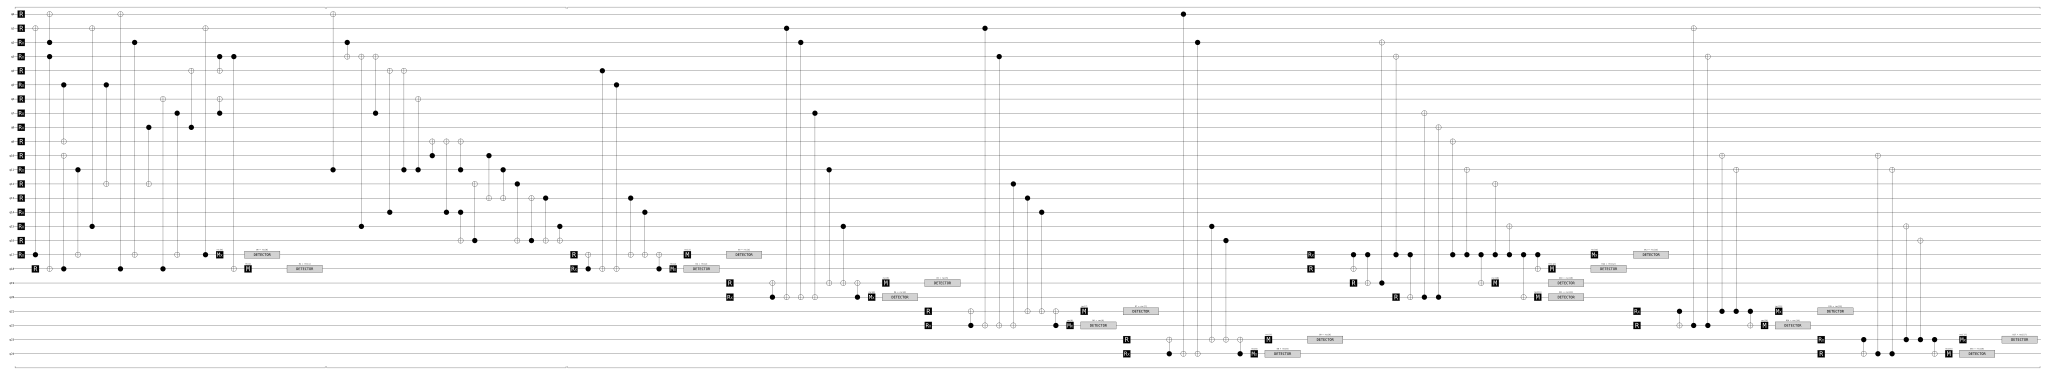

In [36]:
final_circ.diagram('timeline-svg')

In [37]:
final_circ.num_qubits

25

In [72]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_x.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
